## Here we will understand how the Fault Tolerance works in Langgraph

In [24]:
from typing import TypedDict
from langgraph.graph import StateGraph,END
from langgraph.checkpoint.memory import InMemorySaver
import time

In [25]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    done:  bool

In [26]:
# We will stop the workflow process while it was still executing step 2

def step_1(state: CrashState) -> CrashState:
    print("Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(10)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("Step 3 executed")
    return {"done": True}

In [27]:
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

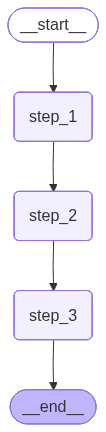

In [28]:
graph

In [29]:
try:
    print("Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("Kernel manually interrupted (crash simulated).")

Running graph: Please manually interrupt during Step 2...
Step 1 executed
Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
Kernel manually interrupted (crash simulated).


In [30]:
print("Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("Final State:", final_state)

Re-running the graph to demonstrate fault tolerance...
Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
Step 3 executed
Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'done': True}


In [31]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'done': True}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f149940-e208-6819-8003-5b89944ebf18'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-06T21:39:26.619637+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f149940-e205-6f4b-8002-b0c182262380'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f149940-e205-6f4b-8002-b0c182262380'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-06T21:39:26.618581+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f149940-4225-694f-8001-68fa0cd87dc2'}}, tasks=(PregelTask(id='22f42aeb-e05d-6986-37